## Case Study: Predicting EV Range Anxiety

This notebook analyzes a dataset related to Electric Vehicle (EV) adoption, behavior, and range anxiety. Range anxiety is a common concern among potential EV buyers, referring to the fear that an EV has insufficient range to reach its destination, thereby stranding the driver. Understanding factors influencing range anxiety is crucial for promoting EV adoption.

**Objective:**
To build a predictive model that can identify individuals prone to high range anxiety based on various demographic, economic, and behavioral factors. This can help EV manufacturers and policymakers to tailor strategies for alleviating range anxiety and accelerating EV market penetration.

**Steps involved:**
1.  **Data Loading:** Load the EV dataset.
2.  **Data Preprocessing:** Handle missing values, encode categorical features, and prepare the data for modeling.
3.  **Exploratory Data Analysis (EDA):** Visualize relationships and distributions to gain insights.
4.  **Model Training:** Train a Random Forest Classifier to predict range anxiety levels.
5.  **Model Evaluation:** Assess the performance of the trained model.
6.  **Prediction:** Demonstrate how the model can be used to make predictions on new data.

This cell imports the `kagglehub` library, which is used to download datasets from Kaggle. It then downloads the specified EV adoption dataset and prints the local path where the files are stored.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("itzzomkar/ev-adoption-behavior-and-range-anxiety")

print("Path to dataset files:", path)

100%|██████████| 153k/153k [00:00<00:00, 37.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/versions/1


This cell constructs the full file path to the `EV_Adoption_and_Range_Anxiety_Dataset.csv` file, combining the downloaded dataset path with the specific CSV filename.

In [ ]:
p=path+"/EV_Adoption_and_Range_Anxiety_Dataset.csv"


This cell imports the `pandas` library for data manipulation and `numpy` for numerical operations. It then uses `pd.read_csv()` to load the dataset from the constructed file path (`p`) into a pandas DataFrame named `df`.

In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv(p)


This cell simply displays the entire DataFrame `df`. This is useful for getting a quick overview of the data's content, columns, and initial rows.

In [ ]:
df

,Buyer_ID,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,EV00001,56,Male,44906.0,Rural,18.1,1,Truck,1,0,Yes,4.0,Yes,Low,No
1,EV00002,36,Male,88754.0,Rural,5.0,1,SUV,2,3,Yes,1.0,Yes,Low,No
2,EV00003,42,Male,155958.0,Urban,32.2,2,Sedan,14,3,No,2.0,Yes,Medium,Yes
3,EV00004,31,Male,37059.0,Rural,89.9,1,Sedan,2,1,Yes,4.0,No,Low,No
4,EV00005,48,Female,48552.0,Rural,71.0,1,Sedan,2,0,Yes,3.0,Yes,Low,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,EV09996,50,Male,61279.0,Urban,71.4,1,Sedan,8,3,No,3.0,Yes,Medium,No
9996,EV09997,34,Male,108208.0,Urban,48.0,2,Hatchback,9,7,No,5.0,No,Low,No
9997,EV09998,60,Female,97743.0,Urban,9.0,2,Sedan,10,3,No,5.0,Yes,Low,No
9998,EV09999,31,Female,103628.0,Urban,81.8,2,SUV,10,10,Yes,1.0,Yes,Low,No


This cell prints a concise summary of the DataFrame using `df.info()`. This output includes the column names, number of non-null values, and data types for each column, which helps in identifying missing data and understanding data types.

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Buyer_ID                     10000 non-null  object 
 1   Age                          10000 non-null  int64  
 2   Gender                       10000 non-null  object 
 3   Annual_Income_USD            9822 non-null   float64
 4   City_Type                    10000 non-null  object 
 5   Daily_Commute_km             9819 non-null   float64
 6   Number_of_Cars_Owned         10000 non-null  int64  
 7   Current_Car_Type             10000 non-null  object 
 8   Charging_Stations_Near_Home  10000 non-null  int64  
 9   Charging_Stations_Near_Work  10000 non-null  int64  
 10  Home_Charging_Possible       10000 non-null  object 
 11  Environmental_Concern_Level  9816 non-null   float64
 12  Subsidy_Available            10000 non-null  object 
 13  Range_Anxiety_Lev

This cell displays the first 5 rows of the DataFrame using `df.head()`. This gives a quick peek at the structure and values of the data, which is essential for initial data inspection.

In [ ]:
print(df.head())

  Buyer_ID  Age  Gender  Annual_Income_USD City_Type  Daily_Commute_km  \
0  EV00001   56    Male            44906.0     Rural              18.1   
1  EV00002   36    Male            88754.0     Rural               5.0   
2  EV00003   42    Male           155958.0     Urban              32.2   
3  EV00004   31    Male            37059.0     Rural              89.9   
4  EV00005   48  Female            48552.0     Rural              71.0   

   Number_of_Cars_Owned Current_Car_Type  Charging_Stations_Near_Home  \
0                     1            Truck                            1   
1                     1              SUV                            2   
2                     2            Sedan                           14   
3                     1            Sedan                            2   
4                     1            Sedan                            2   

   Charging_Stations_Near_Work Home_Charging_Possible  \
0                            0                    Yes   
1 

This cell checks for duplicate rows in the DataFrame using `df.duplicated().sum()`. A result of 0 indicates no duplicate rows, meaning each record is unique.

In [ ]:
print(df.duplicated().sum())

0


This cell calculates and prints the sum of null (missing) values for each column in the DataFrame using `df.isnull().sum()`. This helps identify which columns have missing data and how many missing entries they contain.

In [ ]:
print(df.isnull().sum())

Buyer_ID                         0
Age                              0
Gender                           0
Annual_Income_USD              178
City_Type                        0
Daily_Commute_km               181
Number_of_Cars_Owned             0
Current_Car_Type                 0
Charging_Stations_Near_Home      0
Charging_Stations_Near_Work      0
Home_Charging_Possible           0
Environmental_Concern_Level    184
Subsidy_Available                0
Range_Anxiety_Level              0
Will_Buy_EV                      0
dtype: int64


This cell calculates the mode (most frequent value) for the `Annual_Income_USD`, `Daily_Commute_km`, and `Environmental_Concern_Level` columns. These modes will be used to fill the missing values in their respective columns.

In [ ]:
mode_Annual = df['Annual_Income_USD'].mode()[0]
mode_Daily = df['Daily_Commute_km'].mode()[0]
mode_Environmental = df['Environmental_Concern_Level'].mode()[0]

This cell fills the missing (NaN) values in `Annual_Income_USD`, `Daily_Commute_km`, and `Environmental_Concern_Level` columns with their respective modes calculated in the previous step. This is a common strategy for handling missing numerical data.

In [ ]:
df['Annual_Income_USD'] = df['Annual_Income_USD'].fillna(mode_Annual)
df['Daily_Commute_km'] = df['Daily_Commute_km'].fillna(mode_Daily)
df['Environmental_Concern_Level'] = df['Environmental_Concern_Level'].fillna(mode_Environmental)

This cell re-checks and prints the sum of null values for all columns after the imputation step. This verifies that all missing values in the targeted columns have been successfully handled.

In [ ]:
print(df.isnull().sum())

Buyer_ID                       0
Age                            0
Gender                         0
Annual_Income_USD              0
City_Type                      0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Current_Car_Type               0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Home_Charging_Possible         0
Environmental_Concern_Level    0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64


This cell drops the `Buyer_ID` and `Will_Buy_EV` columns from the DataFrame. `Buyer_ID` is likely a unique identifier and not useful for modeling, while `Will_Buy_EV` is a target variable for a different potential prediction task and might be excluded from the current range anxiety prediction task.

In [ ]:
df =df.drop(['Buyer_ID','Will_Buy_EV'],axis=1)

This cell displays the DataFrame `df` again after dropping the specified columns. This allows for a review of the DataFrame's structure and contents following the removal of columns.

In [ ]:
df

,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level
0,56,Male,44906.0,Rural,18.1,1,Truck,1,0,Yes,4.0,Yes,Low
1,36,Male,88754.0,Rural,5.0,1,SUV,2,3,Yes,1.0,Yes,Low
2,42,Male,155958.0,Urban,32.2,2,Sedan,14,3,No,2.0,Yes,Medium
3,31,Male,37059.0,Rural,89.9,1,Sedan,2,1,Yes,4.0,No,Low
4,48,Female,48552.0,Rural,71.0,1,Sedan,2,0,Yes,3.0,Yes,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,50,Male,61279.0,Urban,71.4,1,Sedan,8,3,No,3.0,Yes,Medium
9996,34,Male,108208.0,Urban,48.0,2,Hatchback,9,7,No,5.0,No,Low
9997,60,Female,97743.0,Urban,9.0,2,Sedan,10,3,No,5.0,Yes,Low
9998,31,Female,103628.0,Urban,81.8,2,SUV,10,10,Yes,1.0,Yes,Low


This cell imports the `LabelEncoder` class from scikit-learn's preprocessing module, which is used for encoding categorical labels into numerical format.

In [ ]:
from sklearn.preprocessing import LabelEncoder

This cell defines a list of categorical columns (`categorical_cols`). It then initializes a `LabelEncoder` and iterates through each specified categorical column, applying `fit_transform` to convert the string categories into numerical labels. This is necessary for machine learning models that require numerical input.

In [ ]:
from sklearn.preprocessing import LabelEncoder
categorical_cols = ['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available','Range_Anxiety_Level']

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

This cell displays the DataFrame `df` after the categorical columns have been label encoded. You can now see numerical values in the columns that were previously strings.

In [ ]:
df

,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level
0,56,1,44906.0,0,18.1,1,3,1,0,1,4.0,1,1
1,36,1,88754.0,0,5.0,1,1,2,3,1,1.0,1,1
2,42,1,155958.0,2,32.2,2,2,14,3,0,2.0,1,2
3,31,1,37059.0,0,89.9,1,2,2,1,1,4.0,0,1
4,48,0,48552.0,0,71.0,1,2,2,0,1,3.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,50,1,61279.0,2,71.4,1,2,8,3,0,3.0,1,2
9996,34,1,108208.0,2,48.0,2,0,9,7,0,5.0,0,1
9997,60,0,97743.0,2,9.0,2,2,10,3,0,5.0,1,1
9998,31,0,103628.0,2,81.8,2,1,10,10,1,1.0,1,1


This cell imports `matplotlib.pyplot` and `seaborn`, which are popular Python libraries used for creating static, animated, and interactive visualizations in Python.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

This cell generates and displays a correlation matrix heatmap. `df.corr()` calculates the pairwise correlation between columns, and `sns.heatmap()` visualizes these correlations. `annot=True` shows the correlation values, `cmap='coolwarm'` sets the color scheme, and `fmt='.2f'` formats the annotations to two decimal places. This helps in understanding relationships between variables.

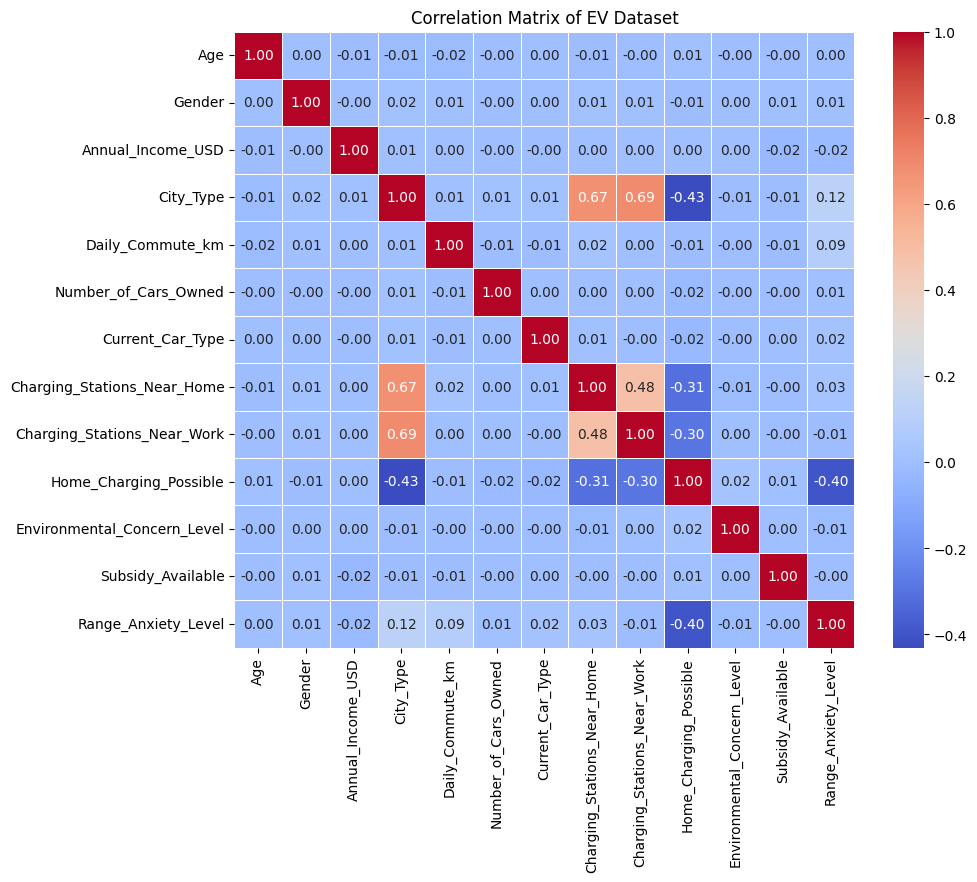

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of EV Dataset')
plt.show()

This cell sets the visual style for Seaborn plots to 'whitegrid' for better readability. It then initializes a new figure for plotting with a specified size (18x5 inches), preparing for multiple subplots.

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 5))

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

This cell creates the first subplot: a count plot showing the distribution of `Range_Anxiety_Level`. It uses a 'Set2' color palette. The title and axis labels are set for clarity. The `(0=Low, 1=Medium, 2=High)` in the xlabel is an interpretation of the label encoding.

/tmp/ipykernel_4486/26061366.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Range_Anxiety_Level', palette='Set2')


Text(0, 0.5, 'Students/Users Count')

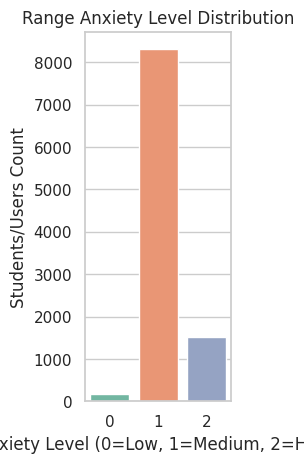

In [ ]:
plt.subplot(1, 3, 1)
sns.countplot(data=df, x='Range_Anxiety_Level', palette='Set2')
plt.title('Range Anxiety Level Distribution')
plt.xlabel('Anxiety Level (0=Low, 1=Medium, 2=High)')
plt.ylabel('Students/Users Count')

This cell generates the second subplot: a box plot comparing `Annual_Income_USD` across different `Range_Anxiety_Level`s. Box plots are good for visualizing the distribution and potential outliers of numerical data for different categories. A 'Pastel1' palette is used.

/tmp/ipykernel_4486/1914666033.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Range_Anxiety_Level', y='Annual_Income_USD', palette='Pastel1')


Text(0, 0.5, 'Annual Income (USD)')

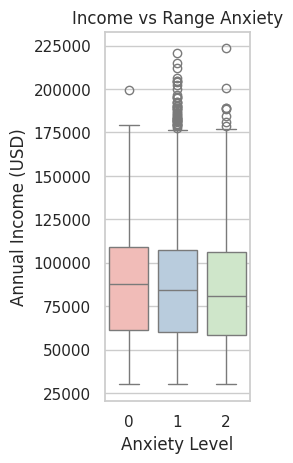

In [ ]:
plt.subplot(1, 3, 2)
sns.boxplot(data=df, x='Range_Anxiety_Level', y='Annual_Income_USD', palette='Pastel1')
plt.title('Income vs Range Anxiety')
plt.xlabel('Anxiety Level')
plt.ylabel('Annual Income (USD)')

This cell creates the third subplot: a bar plot showing the average `Daily_Commute_km` for each `Range_Anxiety_Level`. `errorbar=None` removes confidence intervals. `plt.tight_layout()` adjusts plot parameters for a tight layout, and `plt.show()` displays all three generated plots.

/tmp/ipykernel_4486/678016445.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Range_Anxiety_Level', y='Daily_Commute_km', palette='muted', errorbar=None)


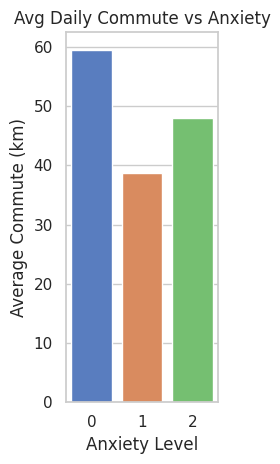

In [ ]:
plt.subplot(1, 3, 3)
sns.barplot(data=df, x='Range_Anxiety_Level', y='Daily_Commute_km', palette='muted', errorbar=None)
plt.title('Avg Daily Commute vs Anxiety')
plt.xlabel('Anxiety Level')
plt.ylabel('Average Commute (km)')
plt.tight_layout()
plt.show()

This cell separates the features (independent variables) from the target variable. `x` contains all columns except `Range_Anxiety_Level`, and `y` contains only the `Range_Anxiety_Level` column. This is a standard step before training a machine learning model.

In [ ]:
x=df.drop(['Range_Anxiety_Level'],axis=1)
y=df['Range_Anxiety_Level']

This cell imports the `train_test_split` function from `sklearn.model_selection`. This function is crucial for splitting a dataset into training and testing subsets, which is necessary for evaluating model performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

This cell splits the dataset (`x` and `y`) into training and testing sets. `test_size=0.2` means 20% of the data will be used for testing, and `random_state=42` ensures reproducibility of the split.

In [ ]:
from numpy import random
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

This cell displays the `x_train` DataFrame, which contains the features used for training the model. It shows the first few rows and columns of the training feature set.

In [ ]:
x_train

,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available
9254,63,1,69093.0,2,30.4,2,1,4,8,0,1.0,1
1561,42,0,163142.0,1,44.4,2,1,5,7,1,5.0,1
1670,46,0,85586.0,2,56.0,1,3,9,3,0,2.0,1
6087,51,0,32870.0,2,71.3,2,1,8,13,0,3.0,1
6669,64,1,117350.0,2,44.4,2,2,11,4,0,4.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5734,38,1,79157.0,2,52.3,1,0,4,18,0,1.0,1
5191,65,0,64077.0,2,17.0,2,2,13,8,1,1.0,1
5390,60,1,90481.0,1,61.9,3,1,3,6,1,5.0,0
860,26,1,107315.0,2,59.3,4,1,4,11,0,4.0,0


This cell displays the `y_test` Series, which contains the actual range anxiety levels for the test set. This will be compared against the model's predictions to evaluate its accuracy.

In [ ]:
y_test

,Range_Anxiety_Level
6252,1
4684,2
1731,1
4742,1
4521,1
...,...
6412,1
8285,1
7853,1
1095,2


This cell imports the `RandomForestClassifier` from `sklearn.ensemble`. It then initializes a Random Forest model with `n_estimators=100` (number of trees), `max_depth=5` (maximum depth of each tree), and `random_state=42` for reproducibility. Finally, it trains the model using the `x_train` and `y_train` data.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100,max_depth=5,random_state=42)
model.fit(x_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

This cell imports `accuracy_score` and `classification_report` from `sklearn.metrics` for model evaluation. It then uses the trained `model` to make predictions (`y_pred`) on the `x_test` dataset.

In [ ]:
from sklearn.metrics import accuracy_score,classification_report
y_pred=model.predict(x_test)


This cell prints the overall accuracy of the Random Forest model by comparing the predicted values (`y_pred`) with the actual test values (`y_test`) using `accuracy_score`.

In [ ]:
print('Accuracy for randam forest:')
print(accuracy_score(y_test,y_pred))


Accuracy for randam forest:
0.8525


This cell displays the DataFrame `df` again. This might be to review the fully processed data after all transformations have been applied.

In [ ]:
df

,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level
0,56,1,44906.0,0,18.1,1,3,1,0,1,4.0,1,1
1,36,1,88754.0,0,5.0,1,1,2,3,1,1.0,1,1
2,42,1,155958.0,2,32.2,2,2,14,3,0,2.0,1,2
3,31,1,37059.0,0,89.9,1,2,2,1,1,4.0,0,1
4,48,0,48552.0,0,71.0,1,2,2,0,1,3.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,50,1,61279.0,2,71.4,1,2,8,3,0,3.0,1,2
9996,34,1,108208.0,2,48.0,2,0,9,7,0,5.0,0,1
9997,60,0,97743.0,2,9.0,2,2,10,3,0,5.0,1,1
9998,31,0,103628.0,2,81.8,2,1,10,10,1,1.0,1,1


This cell defines a sample input `inp` as a list of lists. This `inp` represents a single data point (a potential EV buyer's characteristics) that the trained model can use to make a prediction. The values correspond to the order of features in the processed DataFrame `df`.

In [ ]:
inp =[[56, 1, 44906.0, 0, 18.1, 1, 3, 1, 0, 1, 4.0, 1, 1]]

This cell imports the `joblib` library, which is useful for efficiently saving and loading Python objects, especially large NumPy arrays. It then saves the trained `model` to a file named 'model.pkl' for future use without needing to retrain.

In [ ]:
import joblib
joblib.dump(model,'model.pkl')

['model.pkl']

This cell demonstrates how to use the saved model for prediction. It first loads the 'model.pkl' file back into `loaded_model`. Then, it uses the `loaded_model` to predict the `Range_Anxiety_Level` for the sample input `inp` defined previously, and prints the prediction.

In [ ]:
import joblib

inp = [[56, 1, 44906.0, 0, 18.1, 1, 3, 1, 0, 1, 4.0, 1]]

loaded_model = joblib.load("model.pkl")
predictions = loaded_model.predict(inp)
print("Prediction:", predictions)


Prediction: [1]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
predictions

array([1])